### Problema 4

El comportamiento de un gas puede estudiarse mediante simulaciones de dinámica molecular. En esta práctica implementarás un programa que simule el movimiento de moléculas de hidrógeno ($H_2$) confinadas en una caja tridimensional, considerando colisiones elásticas con las paredes y, opcionalmente, interacciones intermoleculares. El programa permitirá modificar en tiempo real la temperatura y las dimensiones de la caja, y calculará propiedades termodinámicas como temperatura, presión, energía y distribución de velocidades.

El sistema consiste en una caja de dimensiones $L_x$, $L_y$, $L_z$, con paredes reflectantes. Las partículas rebotan elásticamente en las paredes: la componente normal de la velocidad se invierte.

Se consideran $N$ moléculas de hidrógeno ($H_2$) de masa:

$m = 3.32 \times 10^{-27}\ \text{kg}$

(Inicialmente $N = 125$, que puede ajustarse.)

Para modelar un gas real, se puede incluir un potencial de Lennard-Jones:

$$
U_{LJ}(r) = 4\varepsilon \left[\left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6\right]
$$

con parámetros típicos para $H_2$:

$\frac{\varepsilon}{k_B} = 33.3\ \text{K}, \quad \sigma = 0.296\ \text{nm}$

### Parámetros de simulación

- Número de partículas: $N = 125$ (puede ajustarse, pero se recomienda este valor).  
- Dimensiones iniciales de la caja: $L_x = L_y = L_z = 10\ \mu m$.  
- Temperatura inicial: $T_0 = 300\ \text{K}$.  
- Paso de integración: $\Delta t = 1\ \text{ps} = 10^{-12}\ \text{s}$ (ajustable según estabilidad).  
- Constante de Boltzmann: $k_B = 1.380649 \times 10^{-23} \text{J/K}$.

### Tareas a realizar

1. Inicialice las posiciones de las partículas aleatoriamente dentro de la caja. Si se usan interacciones, evite superposiciones iniciales (puede colocarlas en una red cúbica simple con pequeñas perturbaciones).

2. Inicialice las velocidades a temperatura $T_0$.

3. Integre las ecuaciones de movimiento.

4. Incluya colisiones elásticas con las paredes.

5. Agregue controles deslizantes para modificar en tiempo real la temperatura y las dimensiones de la caja.

### Gráficos 2D

1. En ventanas separadas (o subplots) muestre la evolución temporal de:
   - Temperatura $T(t)$ (durante los últimos, por ejemplo, 1000 pasos).
   - Presión $P(t)$.
   - Energía cinética y potencial (si aplica).
   - Histograma de la distribución de velocidades junto con la curva teórica de Maxwell-Boltzmann 3D:  

$$
P(v) =
4\pi \left(\frac{m}{2\pi k_B T}\right)^{3/2}
v^2 \exp\left(-\frac{m v^2}{2 k_B T}\right)
$$

1.- Comenzamos definiendo parametros y la posicion:

In [1]:
import numpy as np

#Parametros

N=125                              #Numero de moleculas
Lx=10e-6                    #Longitud en z de la caja
Ly=Lx
Lz=Lx
T_0=300                              #Temperatura inicial 300K
k_B=1.380649e-23            #Constante de Boltzmann
m=3.32e-27                   #Masa de moleculas         

#Posiciones particulas

Posicion=np.zeros((N,3))             #Arreglo de ceros para ordenar las posiciones de las moleculas en x, y, z
Posicion[:, 0]=np.random.rand(N)*Lx  #Establece una posicion aleatoria para eje x para cada particula ":" entre 0 y 1 y luego es escalado al tamaño de la caja 
Posicion[:, 1]=np.random.rand(N)*Ly
Posicion[:, 2]=np.random.rand(N)*Lz


2.- Para inicializar las velocidades a temperatura $T_{0}$ primero debemos tener en cuenta que un gas en equilibrio termico tiene una distribucion de probabilidad tal que:  

$\text{Probabilidad de cierto estado con energia E} \propto e^{-\frac{E}{k_{B}T}}$  

donde $E$ es la energia cinetica de una particula o molecula:  

$E=\frac{m}{2}(v_{x}^{2}+v_{y}^{2}+v_{z}^{2})$  

Por tanto:  

$\text{Probabilidad de cierto estado con energia E} \propto e^{-\frac{m(v_{x}^{2}+v_{y}^{2}+v_{z}^{2})}{2k_{B}T}}$  

donde podemos separar por componente. De esta manera:  

$P(v_{i}) \propto e^{-\frac{mv_{i}^{2}}{2k_{B}T}} \qquad ; \qquad i=x,y,z $

Y notamos, que tal distribucion de probabilidad es una Gaussiana. La distribucion Gaussiana depende de dos valores, la media y la desviacion estandar. Para esto consideremos lo siguiente. En equilibrio termico se cumple que, para un gas ideal:  

$\langle E \rangle=\frac{3}{2}k_{B}T$  

Y, la energia cinetica promedio de cada molecula:  

$\langle E \rangle=\frac{m}{2}(\langle v_{x}^{2} \rangle +\langle v_{y}^{2} \rangle +\langle v_{z}^{2} \rangle)$  

En un entorno isotropico (sin tendencia) se cumple que:  

$\langle v_{x}^{2} \rangle = \langle v_{y}^{2} \rangle = \langle v_{z}^{2} \rangle $  

Por lo cual, igualando energias, tenemos que:  

$\frac{1}{2}m \cdot 3 \langle v_{x}^{2} \rangle=\frac{3}{2}k_{B}T$  

Despejando el promedio de la velocidad cuadrada:  

$\langle v_{x}^{2} \rangle = \frac{k_{B}T}{m} \qquad o \qquad T=\frac{m \langle v_{x}^{2} \rangle}{k_B} $

Ahora, tambien se cumple que en estas condiciones la media de las velocidades de las particulas es nula:  

$\langle \vec{v} \rangle =0$  

Y, considerando la isotropia:  

$\langle v_{x} \rangle=\langle v_{y} \rangle=\langle v_{z} \rangle=0$  

Por ultimo, la desviacion estandar esta definida como:  

$\sigma^{2}=\langle v^{2} \rangle - \langle v \rangle^{2} $  

En nuestro caso, por componente, esto es:  

$\sigma^{2}=\langle v_{x}^{2} \rangle$  
$\sigma^{2}= \frac{k_{B}T}{m}$  

Entonces, tenemos que:

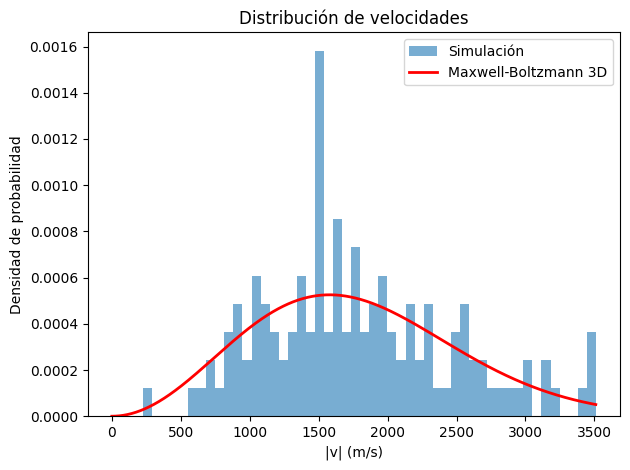

In [2]:
import matplotlib.pyplot as plt

#Media y desviacion estandar

mu=0
sigma=np.sqrt(k_B*T_0 / m)

#Distribucion de velocidades

v=np.zeros((N, 3))                            #Arreglo de ceros para insertar las velocidades

v[:, 0] = np.random.normal(mu, sigma, N)      #Velocidades en x con distribucion de Boltzmann
v[:, 1] = np.random.normal(mu, sigma, N)
v[:, 2] = np.random.normal(mu, sigma, N)

v_mag = np.linalg.norm(v, axis=1)             #np.linalg.norm calcula la norma o modulo de cada velocidad v_{i} (el axis=1 permite eso, toma los elementos por fila)
v_ejes = np.linspace(0, np.max(v_mag), 1000)  #Se crea un arreglo de la magnitud de las velocidad desde 0 hasta la maxima magnitud, con 1000 puntos

#Distribucion teorica 3D Maxwell-Boltzmann

A =4*np.pi * (m / (2*np.pi*k_B*T_0))**(3/2)                     #Constante
dist_MB=A * v_ejes**2 *np.exp(-m* v_ejes**2 / (2*k_B*T_0))        #Distribucion de Maxwell-Boltzmann para temperatuta T=300K

#Grafico

plt.figure()

plt.hist(v_mag, bins=50, density=True, alpha=0.6, label="Simulación")                #Construccion del histograma de simulacion con 50 intervalos (bins), densidad de probabilidad positiva y superposicion del histograma y la curva teorica
plt.plot(v_ejes, dist_MB, 'r', linewidth=2, label="Maxwell-Boltzmann 3D")            #Curva teorica 3D de MB

plt.title("Distribución de velocidades")
plt.xlabel("|v| (m/s)")
plt.ylabel("Densidad de probabilidad")

plt.legend()
plt.tight_layout()
plt.show()


Al tener tan pocas moleculas ($N=125$), el comportamiento colectivo tiene la forma de la distribucion pero notamos diversos peaks que exceden la curva teorica. Notemos el comportamiento para $N=10000$:  

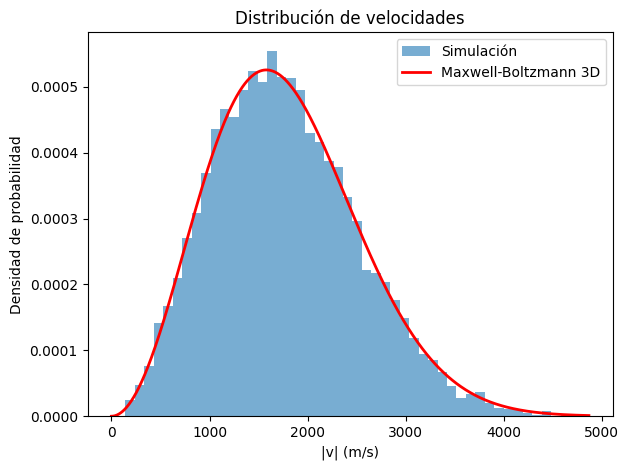

In [3]:
N_grande=10000

#Distribucion de velocidades

v=np.zeros((N_grande, 3))                            #Arreglo de ceros para insertar las velocidades

v[:, 0] = np.random.normal(mu, sigma, N_grande)      #Velocidades en x con distribucion de Boltzmann
v[:, 1] = np.random.normal(mu, sigma, N_grande)
v[:, 2] = np.random.normal(mu, sigma, N_grande)

v_mag = np.linalg.norm(v, axis=1)             #np.linalg.norm calcula la norma o modulo de cada velocidad v_{i}
v_ejes = np.linspace(0, np.max(v_mag), 1000)  #Se crea un arreglo de la magnitud de las velocidad desde 0 hasta la maxima magnitud, con 1000 puntos

#Distribucion teorica 3D Maxwell-Boltzmann

A =4*np.pi * (m / (2*np.pi*k_B*T_0))**(3/2)                       #Constante
dist_MB=A * v_ejes**2 *np.exp(-m* v_ejes**2 / (2*k_B*T_0))        #Distribucion de Maxwell-Boltzmann para temperatuta T=300K

#Grafico

plt.figure()

plt.hist(v_mag, bins=50, density=True, alpha=0.6, label="Simulación")                
plt.plot(v_ejes, dist_MB, 'r', linewidth=2, label="Maxwell-Boltzmann 3D")            

plt.title("Distribución de velocidades")
plt.xlabel("|v| (m/s)")
plt.ylabel("Densidad de probabilidad")

plt.legend()
plt.tight_layout()
plt.show()


3.- Para resolver las ecuaciones de movimiento utilizare el metodo de Euler.  

Para un paso de tiempo $\Delta t$, el método de Euler actualiza:

$$
\vec{v}(t+\Delta t) = \vec{v}(t) + \vec{a}(t)\,\Delta t
$$

$$
\vec{x}(t+\Delta t) = \vec{x}(t) + \vec{v}(t)\,\Delta t
$$

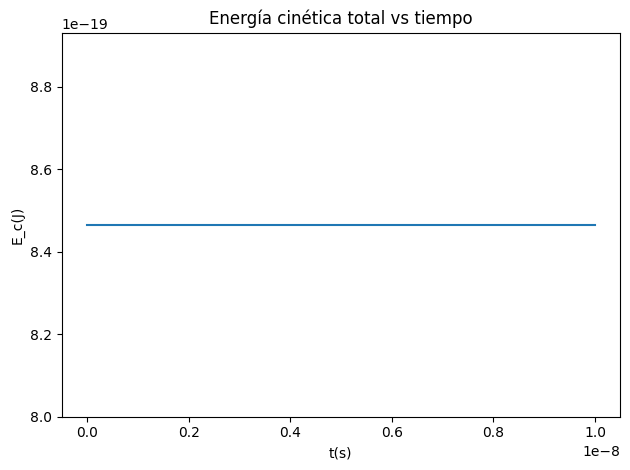

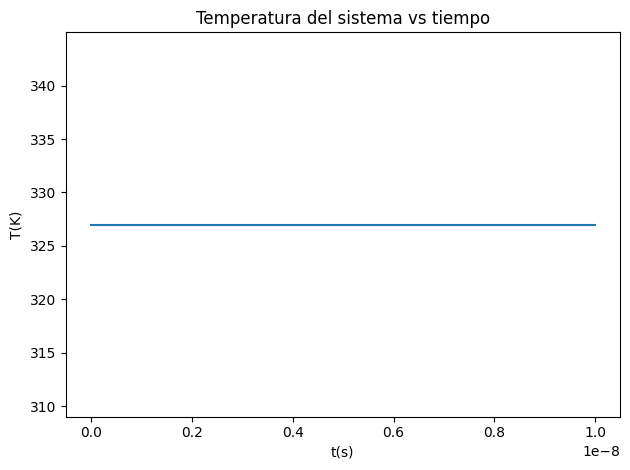

In [ ]:
Posicion=np.zeros((N,3))             #Reinicio posiciones y velocidades
Posicion[:, 0]=np.random.rand(N)*Lx  
Posicion[:, 1]=np.random.rand(N)*Ly
Posicion[:, 2]=np.random.rand(N)*Lz

v=np.zeros((N, 3))                            

v[:, 0] = np.random.normal(mu, sigma, N)      
v[:, 1] = np.random.normal(mu, sigma, N)
v[:, 2] = np.random.normal(mu, sigma, N)

Paso=1e-11                             #Distancia entre puntos
Num_paso=1000                            #Numero de puntos

#Listas

t_lista=[]                               #Lista para el arreglo de tiempos (pasos)
Ec_lista=[]                              #Lista para el arreglo de energias cineticas para los distintos valores de velocidad
T_lista=[]                               #Lista para la temperatura

#Ciclo para la integracion

for i in range(Num_paso):
    t=i*Paso
    Posicion=Posicion+v*Paso                           #Actualizacion de posicion de molecula   

    #Energia cinetica                                    
    v2=np.sum(v**2, axis=1)                            #Velocidades al cuadrado de las moleculas: |v_i|^2
    Ec_particulas=0.5*m*v2                             #Energia cinetica por cada molecula
    Ec_total=np.sum(Ec_particulas)                     #Energia cinetica total del sistema

    #Temperatura

    v2_prom=np.mean(v2)                                #Promedio de velocidad al cuadrado por molecula
    T=(m/(3*k_B))*v2_prom                              #Temperatura 
    t_lista.append(t)
    Ec_lista.append(Ec_total)
    T_lista.append(T)

#Notemos que no hay actualizacion de la velocidad, esto es porque no hay aceleracion en nuestro sistema

#Graficos

plt.figure()

plt.plot(t_lista, Ec_lista)

plt.title("Energía cinética total vs tiempo")
plt.xlabel("t(s)")
plt.ylabel("E_c(J)")

plt.tight_layout()
plt.show()

plt.figure()

plt.plot(t_lista, T_lista)

plt.title("Temperatura del sistema vs tiempo")
plt.xlabel("t(s)")
plt.ylabel("T(K)")

plt.tight_layout()
plt.show()

Este es el comportamiento esperado, ya que no se consideran fuerzas externas o de interaccion, por tanto la energia no debe cambiar y, por consiguiente, la temperatura tampoco.

4.- Incluya colisiones elasticas con las paredes. 

Cuando incluimos colisiones elasticas con las paredes aparece una nueva variable, la presion. Sabemos que la presion se define como:  

$$
P=\frac{F}{A}
$$  

donde $F$ es la fuerza aplicada sobre una superficie $A$. Y la fuerza es tal que:  

$$
F=\frac{\Delta p}{\Delta t}
$$  

donde $\Delta p$ es el cambio de momento de entre un instante de tiempo $t_{1}$ a $t_{2}$ y $\Delta t = t_{2}-t_{1}$. Por tanto, la presion:  

$$
P=\frac{\Delta p}{A\Delta t}
$$  

Ahora, sabemos que, por ejemplo, en el eje $x$, el momento antes de chocar con la pared es $p_{x}=mv_{x}$. Luego de la colision, tenemos que el momento se convierte en $p_{x}=-mv_{x}$. Por lo cual, el cambio de momento estara dado por $\Delta p_{x}=-2mv_{x}$ y, su magnitud $|\Delta p_{x}|=2m|v_{x}|$. Entonces:  

$$
P_{x}=\frac{2m|v_{x}|}{A\Delta t}
$$

Luego, la presion se calcula tal que:  

$$
P=\frac{P_{x}+P_{y}+P_{z}}{3}
$$

Para esto consideraremos que si la particula, por ejemplo, en el eje $x$ se encuentra antes de $x=0$ o despues de $x=L_{x}$ cambiara el signo de su velocidad (rebota en la pared) y se establecera su posicion en $x=0$ o $x=L_{x}$, respectivamente:

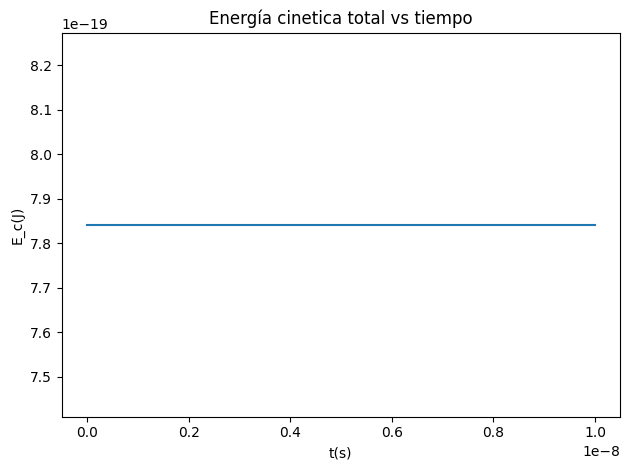

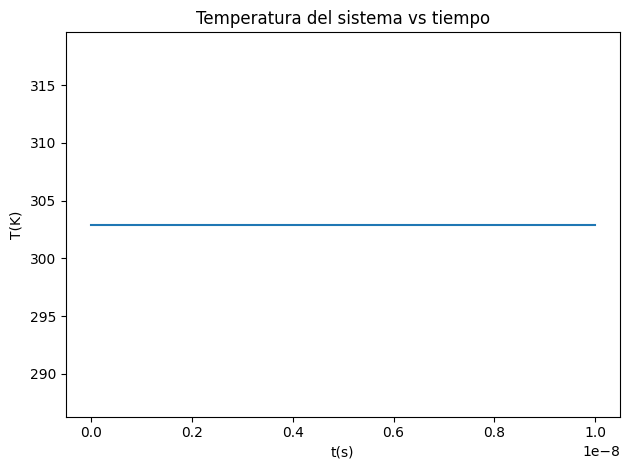

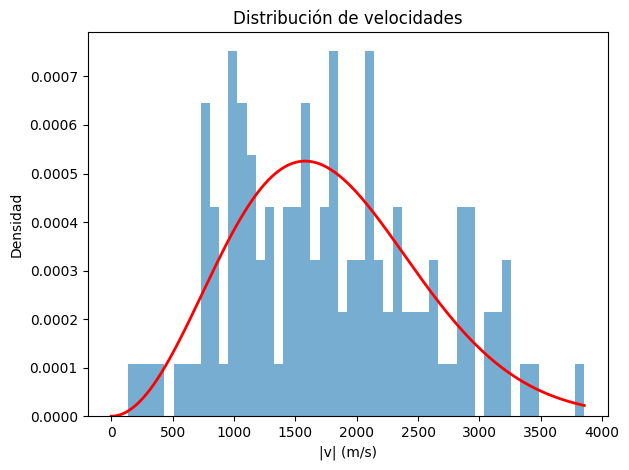

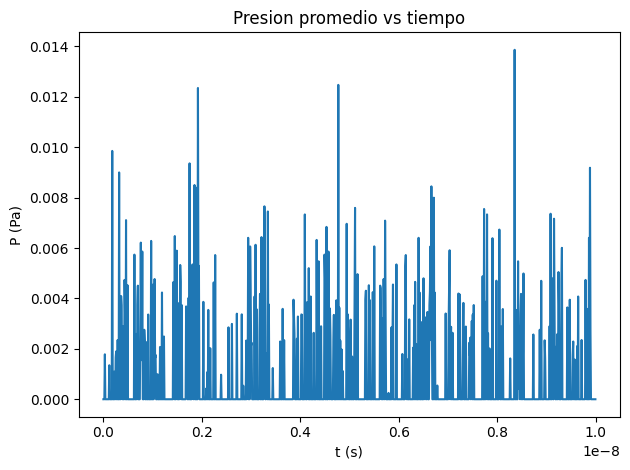

In [10]:
Posicion=np.zeros((N,3))             #Reinicio posiciones y velocidades
Posicion[:, 0]=np.random.rand(N)*Lx  
Posicion[:, 1]=np.random.rand(N)*Ly
Posicion[:, 2]=np.random.rand(N)*Lz

v=np.zeros((N, 3))                            

v[:, 0]=np.random.normal(mu, sigma, N)      
v[:, 1]=np.random.normal(mu, sigma, N)
v[:, 2]=np.random.normal(mu, sigma, N)

#Comparacion con curva teorica

v_mag = np.linalg.norm(v, axis=1)            
v_ejes = np.linspace(0, np.max(v_mag), 1000)  

#Distribucion teorica 3D Maxwell-Boltzmann

A =4*np.pi * (m / (2*np.pi*k_B*T_0))**(3/2)                     
dist_MB=A * v_ejes**2 *np.exp(-m* v_ejes**2 / (2*k_B*T_0))      

#Areas de las caras de la caja 
 
Ax=Ly*Lz 
Ay=Lx*Lz 
Az=Lx*Ly

#Ciclo considerando rebotes

t_lista=[]
Ec_lista=[]
T_lista=[]
P_lista=[]                              #Nueva lista para la presion

for i in range(Num_paso):
    t=i*Paso
    Posicion=Posicion+v*Paso
    Deltap_x = 0
    Deltap_y = 0
    Deltap_z = 0   
    for j in range(N):                               #Rebotes
        if Posicion[j, 0] < 0:                       #Si la molecula j en el eje x esta fuera de la caja por la izquierda (x=0) se retorna a la region permitida en x=0, luego se aplica el efecto rebote cambiando el signo a la velocidad
            Posicion[j, 0] = 0
            Deltap_x = Deltap_x + 2*m*abs(v[j,0])    #Se incluye la magnitud del cambio de momento por la colision de la molecula j para eje x
            v[j, 0] *= -1                            #El *= multiplica por cierto valor a la variable. En este caso, por "-1" ya que la molecula choca con la pared y se devuelve
        elif Posicion[j, 0] > Lx:
            Posicion[j, 0] = Lx
            Deltap_x = Deltap_x + 2*m*abs(v[j,0])
            v[j, 0] *= -1
        if Posicion[j, 1] < 0:
            Posicion[j, 1] = 0
            Deltap_y = Deltap_y + 2*m*abs(v[j,1])
            v[j, 1] *= -1
        elif Posicion[j, 1] > Ly:
            Posicion[j, 1] = Ly
            Deltap_y = Deltap_y + 2*m*abs(v[j,1])
            v[j, 1] *= -1
        if Posicion[j, 2] < 0:
            Posicion[j, 2] = 0
            Deltap_z = Deltap_z + 2*m*abs(v[j,2])
            v[j, 2] *= -1
        elif Posicion[j, 2] > Lz:
            Posicion[j, 2] = Lz
            Deltap_z = Deltap_z + 2*m*abs(v[j,2])
            v[j, 2] *= -1

    #Presion
    Px=Deltap_x/(Ax*Paso)
    Py=Deltap_y / (Ay*Paso)  
    Pz=Deltap_z / (Az*Paso)                                          
    P=(Px+Py+Pz)/3               #Presion
    
    #Energia cinetica
    v2=np.sum(v**2, axis=1)
    Ec=(1/2)*m*np.sum(v2)
    
    #Temperatura
    T=(m*np.mean(v2)/(3*k_B))

    #Agrego valores a listas por molecula
    t_lista.append(t)
    Ec_lista.append(Ec)
    T_lista.append(T)
    P_lista.append(P)

#Graficos

plt.figure()

plt.plot(t_lista, Ec_lista)

plt.title("Energía cinetica total vs tiempo")
plt.xlabel("t(s)")
plt.ylabel("E_c(J)")

plt.tight_layout()
plt.show()

plt.figure()

plt.plot(t_lista, T_lista)

plt.title("Temperatura del sistema vs tiempo")
plt.xlabel("t(s)")
plt.ylabel("T(K)")

plt.tight_layout()
plt.show()

v_mag = np.linalg.norm(v, axis=1)

plt.figure()

plt.hist(v_mag, bins=50, density=True, alpha=0.6)

plt.title("Distribución de velocidades")
plt.plot(v_ejes, dist_MB, 'r', linewidth=2, label="Maxwell-Boltzmann 3D")
plt.xlabel("|v| (m/s)")
plt.ylabel("Densidad")

plt.tight_layout()
plt.show()

plt.figure()

plt.plot(t_lista, P_lista)

plt.title("Presion promedio vs tiempo")
plt.xlabel("t (s)")
plt.ylabel("P (Pa)")

plt.tight_layout()
plt.show()

5.- Agrega controles deslizantes para modificar en tiempo real la temperatura y las dimensiones de la caja.  

Para esto utilizo el mismo codigo, pero dentro de una funcion que tendra como variables la temperatura y las longitudes de la caja:

In [ ]:
from ipywidgets import interact

def simulacion(T_0=300, Lx=10e-6, Ly=10e-6, Lz=10e-6):
    #Parametros
    N=125
    k_B=1.380649e-23
    m=3.32e-27
    Paso=1e-11
    Num_paso=1000

    Posicion=np.random.rand(N,3)*np.array([Lx, Ly, Lz])
    sigma=np.sqrt(k_B*T_0 / m)
    v=np.random.normal(0, sigma, (N,3))

    #Areas de las paredes
    Ax=Ly*Lz
    Ay=Lx*Lz
    Az=Lx*Ly

    # Listas
    t_lista = []
    P_lista = []

    for i in range(Num_paso):
        Posicion=Posicion+v*Paso
        Deltap_x=0
        Deltap_y=0
        Deltap_z=0
        for j in range(N):                               
            if Posicion[j, 0] < 0:                       
                Posicion[j, 0] = 0
                Deltap_x = Deltap_x + 2*m*abs(v[j,0])    
                v[j, 0] *= -1                            
            elif Posicion[j, 0] > Lx:
                Posicion[j, 0] = Lx
                Deltap_x = Deltap_x + 2*m*abs(v[j,0])
                v[j, 0] *= -1
            if Posicion[j, 1] < 0:
                Posicion[j, 1] = 0
                Deltap_y = Deltap_y + 2*m*abs(v[j,1])
                v[j, 1] *= -1
            elif Posicion[j, 1] > Ly:
                Posicion[j, 1] = Ly
                Deltap_y = Deltap_y + 2*m*abs(v[j,1])
                v[j, 1] *= -1
            if Posicion[j, 2] < 0:
                Posicion[j, 2] = 0
                Deltap_z = Deltap_z + 2*m*abs(v[j,2])
                v[j, 2] *= -1
            elif Posicion[j, 2] > Lz:
                Posicion[j, 2] = Lz
                Deltap_z = Deltap_z + 2*m*abs(v[j,2])
                v[j, 2] *= -1
        
        #Presion
        Px=Deltap_x/(Ax*Paso)
        Py=Deltap_y/(Ay*Paso)
        Pz=Deltap_z/(Az*Paso)
        P=(Px+Py+Pz)/3

        # Guardar
        t_lista.append(i*Paso)
        P_lista.append(P)

    #Grafico

    plt.figure()
    plt.plot(t_lista, P_lista, alpha=0.4, label="Presión")

    plt.title(f"T = {T_0} K")
    plt.xlabel("t (s)")
    plt.ylabel("P (Pa)")
    plt.legend()
    plt.tight_layout()
    plt.show()

interact(simulacion, T_0=(100, 600, 50), Lx=(5e-6, 20e-6, 1e-6),Ly=(5e-6, 20e-6, 1e-6), Lz=(5e-6, 20e-6, 1e-6)) #El primer valor de las tuplas es el valor minimo, luego el valor maximo y por ultimo el paso entre cada cambio

interactive(children=(IntSlider(value=300, description='T_0', max=600, min=100, step=50), FloatSlider(value=1e…

<function __main__.simulacion(T_0=300, Lx=1e-05, Ly=1e-05, Lz=1e-05)>

Por ultimo, agregaremos el potencial de Lennard-Jones:  

$$
U_{LJ}(r) = 4\varepsilon \left[\left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6\right]
$$

donde $r$ es la magnitud de la distancia entre dos moleculas. Recordemos que la fuerza inducida por este potencial puede escribirse tal que:  

$$
\vec{F}=-\nabla U
$$

De esta manera, obtenemos que la fuerza:  

$$
\vec{F}=24\varepsilon \left[ 2\left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6 \right] \frac{\vec{r}}{r^{2}}
$$  

Dado que ahora esta presente una fuerza, las moleculas experimentaran una aceleracion. Entonces, se define:  

In [ ]:
def Energia_pot(Posicion, N, epsilon, Sigma):                 #Argumentos: Arreglo de las posiciones de las moleculas, el numero de moleculas, constantes de potencial
    U = 0                                                     #Energia de partida
    for i in range(N):                                        #Recorremos todas las moleculas
        for j in range(i+1, N):                               #Hacemos interactuar a la molecula i con la molecula j (el i+1 es para que no se repita una molecula)
            rij=Posicion[i] - Posicion[j]                     #Distancia entre molecula i y molecula j
            r=np.linalg.norm(rij)                             #Magnitud de la distancia entre molecula i y molecula j
            if r < 0.1*Sigma:                                 #Este "if" es para que no explote F para "r" muy pequeño
                continue                    
            elif r < 3*Sigma:                                 #Se usa esta decision ya que cuando "r=3sigma" o mas la fuerza es practicamente nula, solo es costo computacional
                U= U+4*epsilon*((Sigma/r)**12 - (Sigma/r)**6)
    return U

def Fuerza_int(Posicion, N, epsilon, Sigma):                  
    F=np.zeros_like(Posicion)                                 #Creamos lista para guerdar las fuerzas que tenga el mismo numero de elementos que la posicion
    for i in range(N):                                        
        for j in range(i+1, N):                               
            rij=Posicion[i] - Posicion[j]                     
            r=np.linalg.norm(rij)                             
            if r < 0.1*Sigma:                                                
                continue                                                           
            elif r < 3*Sigma:                                                        
                fij=(24*epsilon*(2*(Sigma/r)**12 - (Sigma/r)**6)/r**2)*rij           #Fuerza entre molecula i y molecula j
                F[i] += fij                                                          #Guardamos accion y reaccion entre moleculas i, y todas las otras moleculas j
                F[j] -= fij
    return F  

Ahora simplemente agregamos esta funcion a nuestro codigo anterior para que modifique la aceleracion. Esto es:

In [42]:
Lx=1e-9                                                   #La razon de hacer la caja mas pequeña es porque el potencial utilizado es del orden de 1e-10, por tanto para una caja de lado 1e-6 las moleculas no se ven                                               
Ly=1e-9
Lz=1e-9

#Defino una red cubica

def inicializar_posiciones(N, Lx, Ly, Lz):
    n = int(np.ceil(N**(1/3)))                            #Numero de puntos por cada eje (x,y,z)
    xs = np.linspace(0, Lx, n)                            #Separa los puntos
    ys = np.linspace(0, Ly, n)
    zs = np.linspace(0, Lz, n)

    Posiciones = []                                              #Lista para guardar posiciones
    for x in xs:                                                 #Ciclo que recorre todo los puntos para formar la red
        for y in ys:
            for z in zs:
                Posiciones.append([x,y,z])

    return np.array(Posiciones[:N])                              #Retorna un arreglo de las posiciones para las N moleculas

def simulacion_con_interaccion(T_0=300, Lx=1e-9, Ly=1e-9, Lz=1e-9):
    #Parametros 
    N=125
    k_B=1.380649e-23
    m=3.32e-27
    Paso=1e-16
    Num_paso=1000
    epsilon=33.3*k_B
    Sigma=0.296e-9

    #Posiciones iniciales
    Posicion=inicializar_posiciones(N, Lx, Ly, Lz)                #Posiciones iniciales en la red cubica

    #Velocidades
    sigma=np.sqrt(k_B*T_0 / m)
    v=np.random.normal(0, sigma, (N,3))

    #Areas
    Ax=Ly*Lz
    Ay=Lx*Lz
    Az=Lx*Ly

    #Listas
    t_lista=[]
    P_lista=[]
    Ec_lista=[]
    T_lista=[]
    U_lista=[]
    for i in range(Num_paso):
        F=Fuerza_int(Posicion, N, epsilon, Sigma)
        a=F/m
        Posicion=Posicion+v*Paso
        v=v+a*Paso
        U = Energia_pot(Posicion, N, epsilon, Sigma)          
        Deltap_x=0
        Deltap_y=0
        Deltap_z=0
        for j in range(N):
            if Posicion[j,0] < 0:
                Posicion[j,0] = 0
                Deltap_x=Deltap_x+2*m*abs(v[j,0])
                v[j,0] *= -1
            elif Posicion[j,0] > Lx:
                Posicion[j,0] = Lx
                Deltap_x=Deltap_x+2*m*abs(v[j,0])
                v[j,0] *= -1
            if Posicion[j,1] < 0:
                Posicion[j,1] = 0
                Deltap_y=Deltap_y+2*m*abs(v[j,1])
                v[j,1] *= -1
            elif Posicion[j,1] > Ly:
                Posicion[j,1] = Ly
                Deltap_y=Deltap_y+2*m*abs(v[j,1])
                v[j,1] *= -1
            if Posicion[j,2] < 0:
                Posicion[j,2] = 0
                Deltap_z=Deltap_z+2*m*abs(v[j,2])
                v[j,2] *= -1
            elif Posicion[j,2] > Lz:
                Posicion[j,2] = Lz
                Deltap_z=Deltap_z+2*m*abs(v[j,2])
                v[j,2] *= -1

        #Presion
        Px=Deltap_x/(Ax*Paso)
        Py=Deltap_y/(Ay*Paso)
        Pz=Deltap_z/(Az*Paso)
        P=(Px+Py+Pz)/3

        #Energia cinetica
        v2=np.sum(v**2, axis=1)
        Ec=0.5*m*np.sum(v2)

        #Temperatura
        T=(m/(3*k_B))*np.mean(v2)

        #Guardo
        t_lista.append(i*Paso)
        P_lista.append(P)
        Ec_lista.append(Ec)
        T_lista.append(T)
        U_lista.append(U)

    plt.figure()
    plt.plot(t_lista, P_lista)
    plt.title("Presión vs tiempo")
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot(t_lista, Ec_lista)
    plt.title("Energía cinética")
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot(t_lista, U_lista)
    plt.title("Energía potencial vs tiempo")
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot(t_lista, T_lista)
    plt.title("Temperatura")
    plt.grid()
    plt.show()

    v_mag = np.linalg.norm(v, axis=1)

    plt.figure()
    plt.hist(v_mag, bins=50, density=True)
    plt.title("Distribución de velocidades")
    plt.grid()
    plt.show()


interact(simulacion_con_interaccion,
         T_0=(100, 600, 50), Lx=(1e-9, 5e-9, 1e-9), Ly=(1e-9, 5e-9, 1e-9), Lz=(1e-9, 5e-9, 1e-9))


interactive(children=(IntSlider(value=300, description='T_0', max=600, min=100, step=50), FloatSlider(value=1e…

<function __main__.simulacion_con_interaccion(T_0=300, Lx=1e-09, Ly=1e-09, Lz=1e-09)>

Si observamos los graficos de presion, energia cinetica y temperatura notamos que comienzan desde un punto muy alto. Esto es porque algunas moleculas se encuentran muy cerca en la simulacion, entregando asi este tipo de comportamientos a la hora de graficar. 